### Gradient Boosting Model for Customer Churn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)

### Load ADASYN-Balanced Dataset

In [2]:
df = pd.read_csv('../mid-data/adasyn_balanced.csv')
target_col = 'Churn'

X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

bool_cols = X.select_dtypes(include=['bool']).columns
if len(bool_cols) > 0:
    X[bool_cols] = X[bool_cols].astype(int)

print('Dataset shape:', df.shape)
print('Feature shape:', X.shape)
print('Target distribution:')
print(y.value_counts())

Dataset shape: (10410, 31)
Feature shape: (10410, 30)
Target distribution:
Churn
1    5236
0    5174
Name: count, dtype: int64


### Train-Test Split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training samples:', X_train.shape[0])
print('Testing samples :', X_test.shape[0])

Training samples: 8328
Testing samples : 2082


### Hyperparameter Tuning (GridSearchCV)

In [4]:
gb = GradientBoostingClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3],
    'subsample': [0.8, 1.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print('Best parameters:', grid_search.best_params_)
print(f'Best CV ROC-AUC: {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV ROC-AUC: 0.9175


### Model Evaluation

In [5]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print('GRADIENT BOOSTING PERFORMANCE')
print(f'Accuracy  : {accuracy:.4f}')
print(f'Precision : {precision:.4f}')
print(f'Recall    : {recall:.4f}')
print(f'F1-score  : {f1:.4f}')
print(f'ROC-AUC   : {roc_auc:.4f}')
print('-' * 70)

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=['Actual No Churn (0)', 'Actual Churn (1)'],
    columns=['Predicted No Churn (0)', 'Predicted Churn (1)']
)

print('Confusion Matrix')
print(cm_df)
print('-' * 70)
print('Classification Report')
print(classification_report(y_test, y_pred))

GRADIENT BOOSTING PERFORMANCE
Accuracy  : 0.8367
Precision : 0.8228
Recall    : 0.8606
F1-score  : 0.8413
ROC-AUC   : 0.9192
----------------------------------------------------------------------
Confusion Matrix
                     Predicted No Churn (0)  Predicted Churn (1)
Actual No Churn (0)                     841                  194
Actual Churn (1)                        146                  901
----------------------------------------------------------------------
Classification Report
              precision    recall  f1-score   support

           0       0.85      0.81      0.83      1035
           1       0.82      0.86      0.84      1047

    accuracy                           0.84      2082
   macro avg       0.84      0.84      0.84      2082
weighted avg       0.84      0.84      0.84      2082



### Confusion Matrix Plot

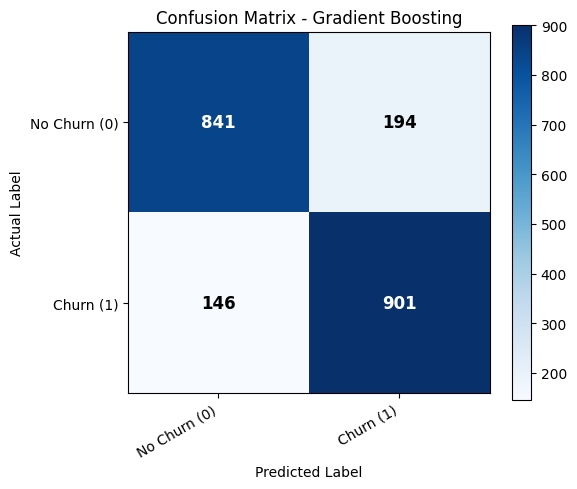

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap=plt.cm.Blues)

classes = ['No Churn (0)', 'Churn (1)']
ax.set_title('Confusion Matrix - Gradient Boosting')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('Actual Label')

ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)

plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

threshold = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i, cm[i, j],
            ha='center',
            va='center',
            fontsize=12,
            fontweight='bold',
            color='white' if cm[i, j] > threshold else 'black'
        )

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

### ROC Curve

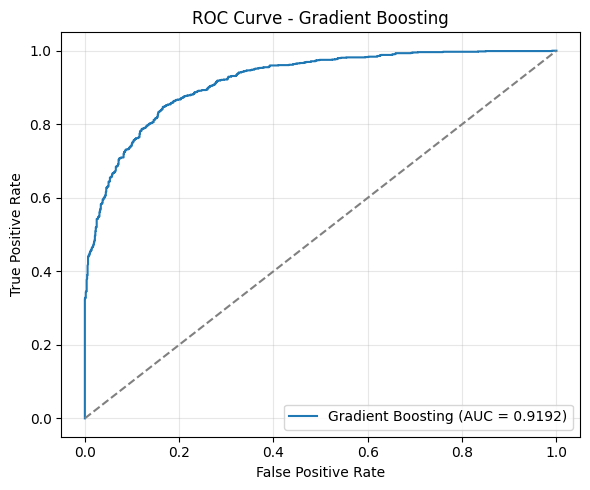

In [7]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Gradient Boosting (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Gradient Boosting')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Top Feature Importances

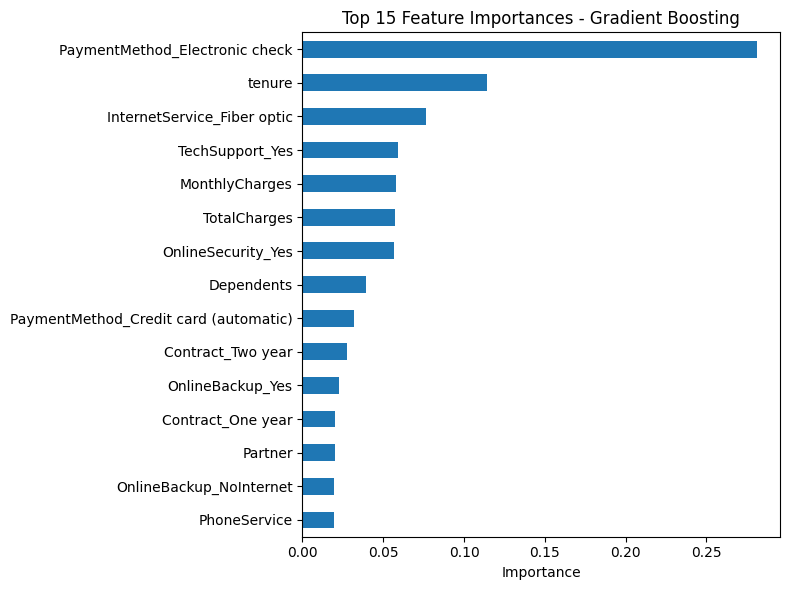

PaymentMethod_Electronic check           0.281484
tenure                                   0.113950
InternetService_Fiber optic              0.076690
TechSupport_Yes                          0.058975
MonthlyCharges                           0.058022
TotalCharges                             0.057435
OnlineSecurity_Yes                       0.056638
Dependents                               0.039162
PaymentMethod_Credit card (automatic)    0.031646
Contract_Two year                        0.027334
OnlineBackup_Yes                         0.022891
Contract_One year                        0.019899
Partner                                  0.019855
OnlineBackup_NoInternet                  0.019661
PhoneService                             0.019516
dtype: float64

In [8]:
importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
top_features.sort_values().plot(kind='barh')
plt.title('Top 15 Feature Importances - Gradient Boosting')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

top_features